# Observatory

Two detection engines, one metric catalog, one snapshot. `pipeline_runs` holds four
daily operations metrics for a fictional nightly model-training pipeline, each with
a deliberately different kind of injected anomaly; `scoring_log` holds five features
from the churn model that pipeline trains, scored for a batch of customers every day,
four of them drifting and one left as a stable control.

This notebook only reads what `src/snapshot.py` already computed: `snapshot/flags.csv`
and `snapshot/events.json`. It queries the two raw panels straight from
`data/observatory.duckdb` for plotting context, but it never reruns a detector or
recomputes popmon; the point of the snapshot architecture is that alerting, the
dashboard, and this notebook all read the same artifacts instead of each doing their
own pass over the data. See the project README for how the two engines are wired
together.

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent / "src"))
from style import set_style, style_ax, savefig, MUTED_AMBER, MUTED_RED, MUTED_TEAL, SLATE

BASE = Path.cwd().parent
FIG_DIR = BASE / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
set_style()

con = duckdb.connect(str(BASE / "data" / "observatory.duckdb"), read_only=True)
ops_df = con.execute((BASE / "sql" / "ops_daily_panel.sql").read_text()).fetchdf()
scoring_df = con.execute((BASE / "sql" / "scoring_daily_panel.sql").read_text()).fetchdf()
con.close()

flags = pd.read_csv(BASE / "snapshot" / "flags.csv")
events = json.loads((BASE / "snapshot" / "events.json").read_text())

print(f"{len(ops_df)} days of pipeline runs, {len(scoring_df):,} scoring rows, {len(events)} alert events")

90 days of pipeline runs, 16,200 scoring rows, 9 alert events


## 1. The ops metrics panel

Four daily metrics for the nightly pipeline: how long it ran, how often it succeeded,
how stale the source data was, how many rows it ingested. Somewhere in each is one
injected anomaly, shaped so a different detector (`src/detectors.py`) is the one that
catches it cleanly.

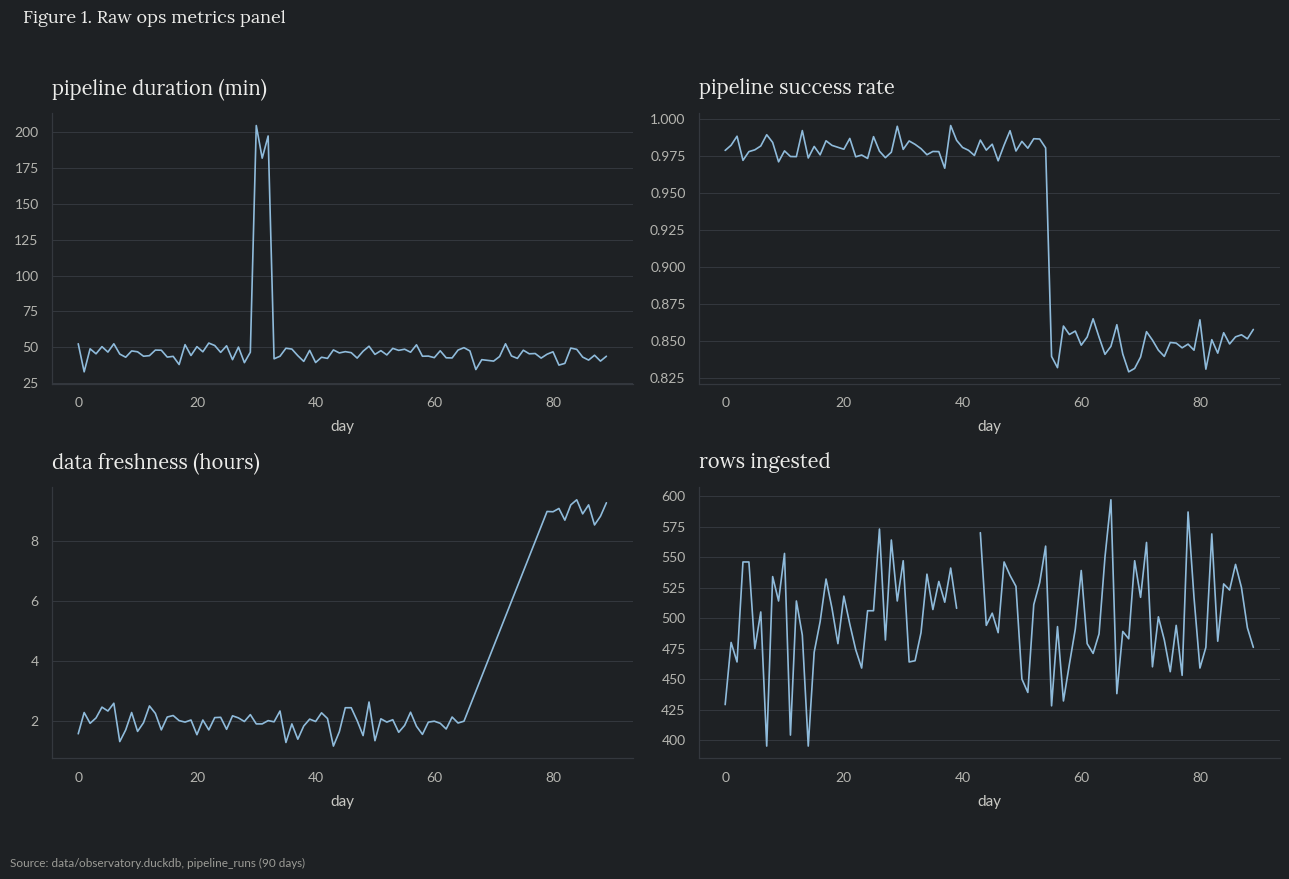

In [2]:
OPS_LABELS = {
    "pipeline_duration_minutes": "pipeline duration (min)",
    "pipeline_success_rate": "pipeline success rate",
    "data_freshness_hours": "data freshness (hours)",
    "row_count": "rows ingested",
}
OPS_METRICS = list(OPS_LABELS)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, metric in zip(axes.flat, OPS_METRICS):
    ax.plot(ops_df["day"], ops_df[metric], color=SLATE, linewidth=1.2)
    style_ax(ax, title=OPS_LABELS[metric], xlabel="day", ylabel=None, grid_axis="y")
fig.suptitle("Figure 1. Raw ops metrics panel", y=1.02, fontsize=13, fontfamily="Lora", color="#ECECEA", x=0.02, ha="left")
savefig(fig, FIG_DIR / "ops_panel.png", footnote="Source: data/observatory.duckdb, pipeline_runs (90 days)")
fig

## 2. What the ops detector engine caught

Every ops metric runs against all four detector types (threshold, z-score, trend-break,
data-gap). The markers below come straight from `flags.csv`, exactly what
`src/snapshot.py` wrote, not a live recomputation.

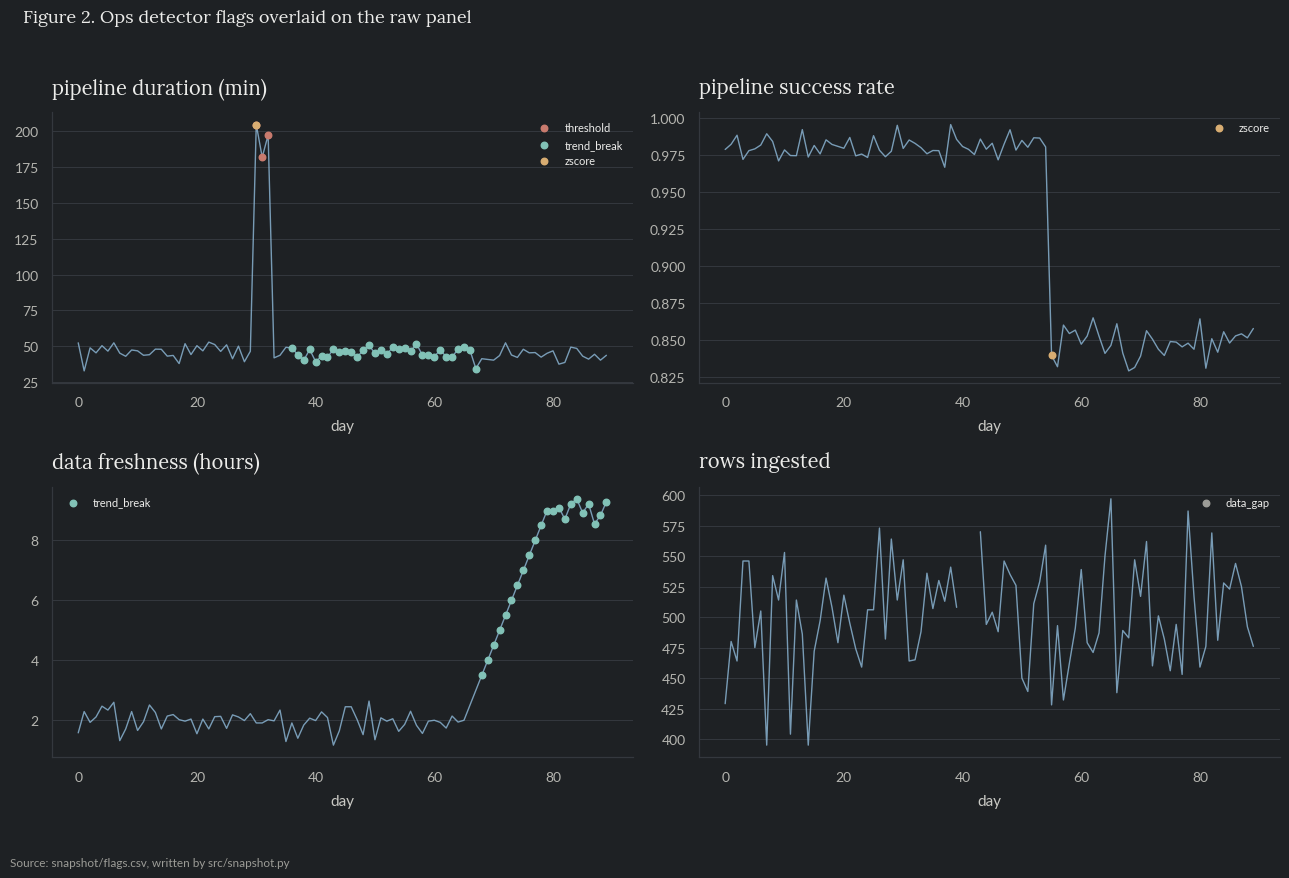

In [3]:
DETECTOR_COLORS = {"threshold": MUTED_RED, "zscore": MUTED_AMBER, "trend_break": MUTED_TEAL, "data_gap": "#9C9C97"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, metric in zip(axes.flat, OPS_METRICS):
    ax.plot(ops_df["day"], ops_df[metric], color=SLATE, linewidth=1.0, zorder=2, alpha=0.8)
    metric_flags = flags[(flags["metric"] == metric) & (flags["flagged"])]
    for detector, group in metric_flags.groupby("detector"):
        matched = ops_df[ops_df["day"].isin(group["day"])]
        ax.scatter(matched["day"], matched[metric], color=DETECTOR_COLORS[detector],
                   label=detector, zorder=3, s=22)
    style_ax(ax, title=OPS_LABELS[metric], xlabel="day", ylabel=None, grid_axis="y")
    ax.legend(fontsize=8, loc="best")
fig.suptitle("Figure 2. Ops detector flags overlaid on the raw panel", y=1.02, fontsize=13, fontfamily="Lora", color="#ECECEA", x=0.02, ha="left")
savefig(fig, FIG_DIR / "ops_detector_flags.png", footnote="Source: snapshot/flags.csv, written by src/snapshot.py")
fig

Two things worth noticing. `pipeline_duration_minutes` gets flagged twice: once by
`threshold`/`zscore` right on the spike (days 30-32), and again by `trend_break` around
day 36, an echo, not a new incident, the three-day window the spike sits in is still
inside `trend_break`'s comparison baseline five days later. `data_freshness_hours` only
crosses `trend_break`'s bar partway through its own ramp, a gradual drift needs enough
bad days inside the window before the comparison to the rolling baseline is large
enough to fire.

## 3. Model feature drift: popmon

Scalar checks don't make sense here, a customer's plan tier isn't a number with a
threshold. `src/stability.py` wraps popmon's `pm_stability_report()`, comparing each
day's feature distribution against a clean 15-day reference period, and
`extract_alerts()` turns its traffic-light output into the same long-form shape the ops
detectors produce. Below: the two clearest cases, a numerical level shift and a
categorical mix shift, computed directly from `scoring_log` for plotting context (the
flags themselves are read from `flags.csv`, not recomputed).

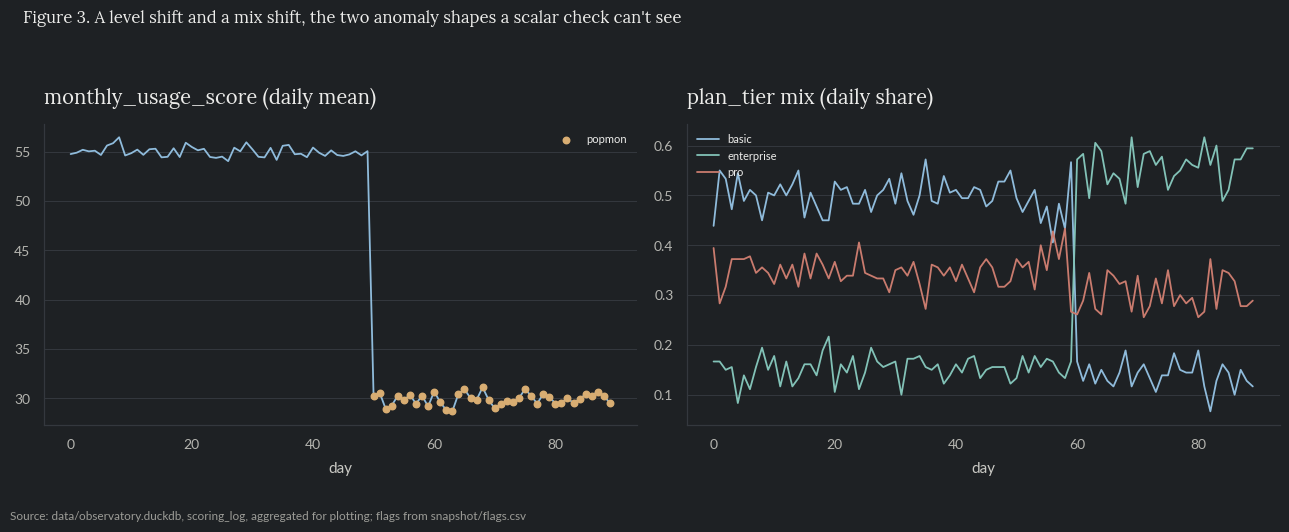

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

usage_daily = scoring_df.groupby("day")["monthly_usage_score"].mean()
axes[0].plot(usage_daily.index, usage_daily.values, color=SLATE, linewidth=1.3)
usage_flags = flags[(flags["metric"] == "monthly_usage_score") & flags["flagged"]]
axes[0].scatter(usage_flags["day"], usage_daily.reindex(usage_flags["day"]).values,
                color=MUTED_AMBER, zorder=3, s=22, label="popmon")
style_ax(axes[0], title="monthly_usage_score (daily mean)", xlabel="day", grid_axis="y")
axes[0].legend(fontsize=8)

plan_share = scoring_df.groupby("day")["plan_tier"].value_counts(normalize=True).unstack()
for tier, color in zip(plan_share.columns, [SLATE, MUTED_TEAL, MUTED_RED]):
    axes[1].plot(plan_share.index, plan_share[tier], label=tier, color=color, linewidth=1.3)
style_ax(axes[1], title="plan_tier mix (daily share)", xlabel="day", grid_axis="y")
axes[1].legend(fontsize=8)

fig.suptitle("Figure 3. A level shift and a mix shift, the two anomaly shapes a scalar check can't see", y=1.05, fontsize=12, fontfamily="Lora", color="#ECECEA", x=0.02, ha="left")
savefig(fig, FIG_DIR / "popmon_drift_examples.png", footnote="Source: data/observatory.duckdb, scoring_log, aggregated for plotting; flags from snapshot/flags.csv")
fig

`monthly_usage_score` steps down around day 50 and popmon catches it a few days into
the new level, once enough post-shift days have accumulated to move the reference-period
comparison. `plan_tier`'s mix flips from basic-heavy to enterprise-heavy at day 60; no
single row looks wrong, only the shape of the distribution has changed, which is exactly
what popmon is built to compare and a threshold or z-score check on a categorical column
has no way to express.

## 4. From flags to alerts: dedup in action

Across all nine monitored metrics, `find_alert_events()` (`src/alerts.py`) collapses
each metric's flagged days into one event per contiguous run, dated to the day the run
starts. Same dedup logic for both engines, ops detectors and popmon both just produce
flagged days; the collapsing step doesn't know or care which engine flagged them.

                           flagged days  alert events
predicted_churn_prob                 62             1
monthly_usage_score                  40             1
pipeline_duration_minutes            35             2
plan_tier                            30             1
data_freshness_hours                 22             1
support_tickets_30d                   5             1
row_count                             3             1
pipeline_success_rate                 1             1


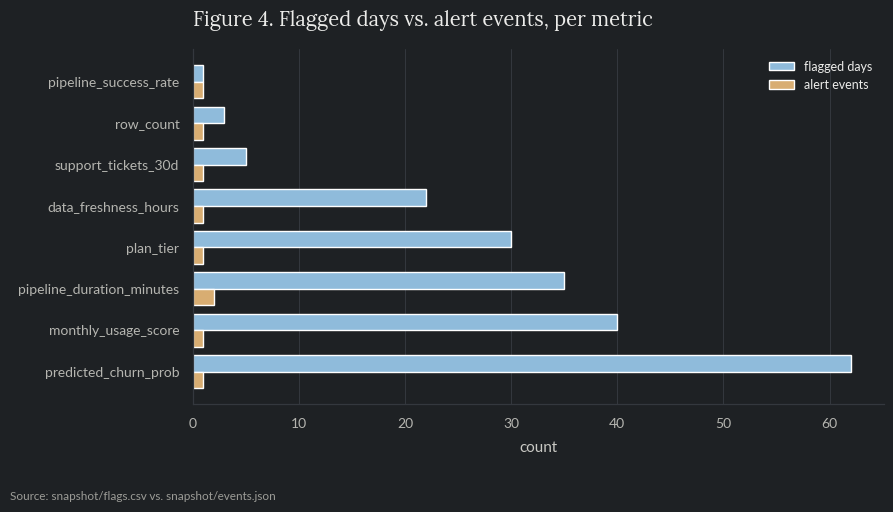

In [5]:
flagged_days = flags[flags["flagged"]].groupby("metric")["day"].nunique()
event_counts = pd.Series({m: sum(1 for e in events if e["metric"] == m) for m in flagged_days.index})
comparison = pd.DataFrame({"flagged days": flagged_days, "alert events": event_counts}).fillna(0).astype(int)
comparison = comparison.sort_values("flagged days", ascending=False)
print(comparison)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = range(len(comparison))
ax.barh([i + 0.2 for i in y], comparison["flagged days"], height=0.4, color=SLATE, label="flagged days")
ax.barh([i - 0.2 for i in y], comparison["alert events"], height=0.4, color=MUTED_AMBER, label="alert events")
ax.set_yticks(list(y))
ax.set_yticklabels(comparison.index)
style_ax(ax, title="Figure 4. Flagged days vs. alert events, per metric", xlabel="count", grid_axis="x")
ax.legend(fontsize=9)
savefig(fig, FIG_DIR / "alert_dedup.png", footnote="Source: snapshot/flags.csv vs. snapshot/events.json")
fig

`pipeline_success_rate` and `data_freshness_hours` stay flagged for the rest of the
90-day window once they cross the line, dozens of flagged days each, but still one alert
event apiece. Without dedup, a monitoring system that pages on every flagged day would
have sent an alert a day for the rest of the observation window on a problem that was
already known.

## 5. The alert log

Real output from `src/snapshot.py`. `ConsoleChannel` printed every line below;
`FileChannel` wrote the same events to `snapshot/alert_log.jsonl`.

In [6]:
for event in events:
    print(f"day {event['day']:>3}  {event['metric']:<24} flagged by {', '.join(event['detectors'])}")

day  28  predicted_churn_prob     flagged by popmon
day  30  pipeline_duration_minutes flagged by threshold, zscore
day  36  pipeline_duration_minutes flagged by trend_break
day  40  row_count                flagged by data_gap
day  50  monthly_usage_score      flagged by popmon
day  55  pipeline_success_rate    flagged by zscore
day  60  plan_tier                flagged by popmon
day  68  data_freshness_hours     flagged by trend_break
day  70  support_tickets_30d      flagged by popmon


## Summary

Two anomaly families need two different kinds of check: a hand-rolled detector engine
for scalar ops metrics (a hard SLA breach, a statistical outlier, a gradual trend break,
a reporting gap), and popmon for model-feature and prediction distributions (a level
shift, a categorical mix shift), both configured from the same metric catalog and
feeding the same dedup logic. Eight of the nine monitored metrics were flagged, each by
the detector suited to its anomaly shape; `tenure_months`, left untouched as a control,
was never flagged. A static dashboard built from the same snapshot (`dashboard/index.html`)
and popmon's own full per-feature report (`snapshot/popmon_stability_report.html`) cover
the same run from a different angle; see the project README.